# 14 — Multi-Policy Generalization Test

**Context:** Notebook 13 showed Condition D (two-step reasoning + anti-sycophancy + numeric scale
+ 50% reversal) nearly eliminates aggregate pro-climate bias for **Ban Petrol Cars**
(Claude mean error: +1.067 → +0.033). However, MAE remained unchanged (~1.7–1.9 floor).

**This notebook** tests whether Condition D generalizes across 3 additional policies with
different content and framing:

| Policy | Framing | Why selected |
|---|---|---|
| **Renewable Energy** | Infrastructure/energy | Most consensual; tests if D overcorrects on high-support topics |
| **Carbon Tax** | Economic/redistributive | "Tax" framing activates different reasoning pathway |
| **Climate Compensation** | International aid | Least salient in LLM training data; different moral framing |

**Design:** Claude only, Conditions A (control) vs D (combined), N=30 agents, seed=44.
~270 API calls total.

**Reference:** NB 13 Ban Petrol Cars results loaded for cross-policy comparison.

In [3]:
# ── Imports ──
import sys, os, logging, time, random, re, json
import pandas as pd
import numpy as np
from datetime import date, datetime
from statistics import mean, stdev
from collections import Counter
from scipy.stats import spearmanr, wilcoxon

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from cag.io.survey import load
from cag.io.llm import load_api_key, send_chat, parse_letter_response
from cag.abm.agent import SurveyedCitizen
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import (
    ClimatePolicyID, SURVEY_COLUMN_MAP, SURVEY_QUESTIONS,
    RESPONSE_SCALE, RESPONSE_LABELS, ordinal_score,
)

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)

logging.basicConfig(level=logging.WARNING)
print("Imports OK")

Imports OK


## Configuration

In [4]:
# ── Experiment config ──
MODEL_NAME = "claude-sonnet-4-6"
MODEL_ID = "claude-sonnet-4-6"
PROVIDER = "anthropic"

CONDITIONS = ["A", "D"]

POLICIES = [
    ClimatePolicyID.RENEWABLE_ENERGY,
    ClimatePolicyID.CARBON_TAX,
    ClimatePolicyID.CLIMATE_COMPENSATION,
]

N_AGENTS = 30
TEMPERATURE = 0.5
THINKING = True
RANDOM_SEED = 44  # same seed as notebooks 11-13 for comparability

# Reverse lookup: ClimatePolicyID instance -> string name
POLICY_NAMES = {}
for _attr in dir(ClimatePolicyID):
    _val = getattr(ClimatePolicyID, _attr)
    if isinstance(_val, ClimatePolicyID):
        POLICY_NAMES[_val] = _attr

api_key = load_api_key(PROVIDER)

print(f"Model: {MODEL_NAME}")
print(f"Policies: {[POLICY_NAMES[p] for p in POLICIES]}")
print(f"Conditions: {CONDITIONS}")
print(f"Agents: {N_AGENTS}, Seed: {RANDOM_SEED}, Temperature: {TEMPERATURE}, Thinking: {THINKING}")
print(f"Estimated API calls: {len(POLICIES) * len(CONDITIONS) * N_AGENTS * 1.5:.0f}")

Model: claude-sonnet-4-6
Policies: ['RENEWABLE_ENERGY', 'CARBON_TAX', 'CLIMATE_COMPENSATION']
Conditions: ['A', 'D']
Agents: 30, Seed: 44, Temperature: 0.5, Thinking: True
Estimated API calls: 270


## Build environment and sample agents

In [5]:
# ── Build the SurveyedNation and sample agents ──
random.seed(RANDOM_SEED)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

sn = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
data = data.sample(n=N_AGENTS, random_state=RANDOM_SEED)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

agents = list(sn.agents_active.values())
print(f"Sampled {len(agents)} agents")

# Ground truth for each agent x policy
ground_truth = {}  # {(agent_id, policy_id): numeric_value}
for agent in agents:
    for policy_id in POLICIES:
        ground_truth[(agent.id, policy_id)] = agent.get_real_survey_response(policy_id)

# Summary per policy
print()
for policy_id in POLICIES:
    vals = [ground_truth[(a.id, policy_id)] for a in agents]
    pname = POLICY_NAMES[policy_id]
    print(f"{pname:25s}  mean={mean(vals):+.3f}  SD={stdev(vals):.3f}  dist={dict(sorted(Counter(vals).items()))}")

Sampled 30 agents

RENEWABLE_ENERGY           mean=+2.233  SD=0.971  dist={0: 2, 1: 5, 2: 7, 3: 16}
CARBON_TAX                 mean=+0.733  SD=1.701  dist={-3: 2, -2: 2, -1: 2, 0: 5, 1: 8, 2: 7, 3: 4}
CLIMATE_COMPENSATION       mean=-0.067  SD=1.799  dist={-3: 3, -2: 5, -1: 4, 0: 6, 1: 5, 2: 5, 3: 2}


## Prompt builders

Reused from notebook 13. Only conditions A (control) and D (combined) are needed.

In [6]:
# ── Prompt builders and response parsers (from NB 13) ──

def parse_numeric_response(response):
    """Extract a single integer -3 to +3 from a free-text LLM response."""
    text = response.strip()
    if not text:
        raise ValueError("Empty response.")

    # Strip markdown formatting: bold (**), italic (*), code (`), underscore bold (__)
    text = re.sub(r'[*_`]', '', text)

    match = re.search(
        r'(?:answer|response|choice|choose|select|rating|score)\s*(?:is|:)?\s*([+-]?[0-3])',
        text, re.IGNORECASE
    )
    if match:
        val = int(match.group(1))
        if -3 <= val <= 3:
            return val

    first_line = text.split('\n')[0].strip()
    match = re.match(r'^([+-]?[0-3])(?:[.,;:\s)]|$)', first_line)
    if match:
        val = int(match.group(1))
        if -3 <= val <= 3:
            return val

    matches = re.findall(r'(?:^|\s)([+-]?[0-3])(?:\s|[.,;:)]|$)', text)
    valid = [int(m) for m in matches if -3 <= int(m) <= 3]
    if valid:
        return valid[0]

    raise ValueError(f"Cannot extract a number -3 to +3 from: {text[:200]}")


# ── Scale builders ──
NUMERIC_SCALE_NORMAL = {
    -3: "Strongly oppose", -2: "Somewhat oppose", -1: "Slightly oppose",
     0: "Neutral",
    +1: "Slightly support", +2: "Somewhat support", +3: "Strongly support",
}
NUMERIC_SCALE_REVERSED = {
    +3: "Strongly support", +2: "Somewhat support", +1: "Slightly support",
     0: "Neutral",
    -1: "Slightly oppose", -2: "Somewhat oppose", -3: "Strongly oppose",
}

def _format_numeric_scale(reversed_order=False):
    scale = NUMERIC_SCALE_REVERSED if reversed_order else NUMERIC_SCALE_NORMAL
    return "\n".join(f"{k:+d} = {v}" for k, v in scale.items())


ANTI_SYCOPHANCY = (
    "Your task is to faithfully simulate how this specific person would respond, "
    "NOT to give the 'correct' or socially desirable answer. "
    "Real people with this profile hold a WIDE range of views on climate policy, "
    "including strong opposition. That is expected and acceptable."
)

STEP1_TEMPLATE = (
    "{anti_sycophancy}\n\n"
    "Given this person's demographic profile, political history, and psychological values, "
    "what factors would shape their view on the following policy?\n\n"
    "{policy_question}\n\n"
    "Consider factors that might lead them to SUPPORT this policy AND factors that might "
    "lead them to OPPOSE it. Think about their voting history, their values, their life "
    "circumstances, and how these might interact.\n\n"
    "Provide your reasoning in 2-3 sentences."
)

STEP2_NUMERIC_TEMPLATE = (
    "Based on the reasoning above, how would this person respond to the following survey question?\n\n"
    "{policy_question}\n\n"
    "Rate your position on the following scale:\n"
    "{scale_str}\n\n"
    "Respond with a single number from -3 to +3."
)


def run_condition_A(agent, policy_id, api_key, model_id, provider):
    """Single-step, letter scale (control)."""
    system_prompt = agent.get_system_prompt(day=0)
    policy_question = SURVEY_QUESTIONS[policy_id]
    response_options = "\n".join(f"{letter}. {label}" for letter, label in RESPONSE_LABELS.items())
    user_prompt = policy_question + "\n\n" + response_options + "\n\nRespond with a single letter A-G."

    llm_response = send_chat(
        system_prompt, user_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )
    letter = parse_letter_response(llm_response)
    numeric = RESPONSE_SCALE[letter]
    return numeric, {"step1_reasoning": None, "reversed": False, "raw_response": llm_response}


def run_condition_D(agent, policy_id, api_key, model_id, provider, agent_index=0):
    """Two-step reasoning + anti-sycophancy + numeric scale + 50% reversal."""
    system_prompt = agent.get_system_prompt(day=0)
    policy_question = SURVEY_QUESTIONS[policy_id]
    reversed_order = (agent_index % 2 == 1)

    step1_prompt = STEP1_TEMPLATE.format(
        anti_sycophancy=ANTI_SYCOPHANCY,
        policy_question=policy_question,
    )
    reasoning = send_chat(
        system_prompt, step1_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )

    scale_str = _format_numeric_scale(reversed_order)
    step2_system = system_prompt + "\n\nYour reasoning about this policy:\n" + reasoning
    step2_prompt = STEP2_NUMERIC_TEMPLATE.format(
        policy_question=policy_question,
        scale_str=scale_str,
    )
    llm_response = send_chat(
        step2_system, step2_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )
    numeric = parse_numeric_response(llm_response)
    return numeric, {"step1_reasoning": reasoning, "reversed": reversed_order, "raw_response": llm_response}


CONDITION_RUNNERS = {"A": run_condition_A, "D": run_condition_D}

print("Prompt builders defined.")
print(f"  A: single-step, A-G letter scale (control)")
print(f"  D: two-step reasoning + anti-sycophancy, numeric -3 to +3 (50% reversed)")

Prompt builders defined.
  A: single-step, A-G letter scale (control)
  D: two-step reasoning + anti-sycophancy, numeric -3 to +3 (50% reversed)


## Run experiment

3 policies x 2 conditions x 30 agents x ~1.5 calls each = **~270 API calls**.

In [7]:
# ── Run multi-policy experiment ──
all_results = []

for policy_id in POLICIES:
    for condition in CONDITIONS:
        pname = POLICY_NAMES[policy_id]
        print(f"\n{'='*60}")
        print(f"{pname} -- Condition {condition}")
        print(f"{'='*60}")

        runner = CONDITION_RUNNERS[condition]
        t0 = time.time()

        for i, agent in enumerate(agents):
            try:
                if condition == "D":
                    numeric, meta = runner(
                        agent, policy_id, api_key, MODEL_ID, PROVIDER,
                        agent_index=i,
                    )
                else:
                    numeric, meta = runner(
                        agent, policy_id, api_key, MODEL_ID, PROVIDER,
                    )

                real = ground_truth[(agent.id, policy_id)]

                all_results.append({
                    "policy": pname,
                    "condition": condition,
                    "agent_id": agent.id,
                    "llm_numeric": numeric,
                    "real_numeric": real,
                    "error": numeric - real,
                    "abs_error": abs(numeric - real),
                    "exact_match": int(numeric == real),
                    "ordinal_score": ordinal_score(numeric, real),
                    "step1_reasoning": meta.get("step1_reasoning"),
                    "reversed_scale": meta.get("reversed", False),
                })

                if (i + 1) % 10 == 0:
                    print(f"  {i+1}/{len(agents)} agents done")

            except Exception as e:
                print(f"  ERROR agent {agent.id}: {e}")
                all_results.append({
                    "policy": pname,
                    "condition": condition,
                    "agent_id": agent.id,
                    "llm_numeric": None,
                    "real_numeric": ground_truth[(agent.id, policy_id)],
                    "error": None,
                    "abs_error": None,
                    "exact_match": 0,
                    "ordinal_score": None,
                    "step1_reasoning": None,
                    "reversed_scale": False,
                })

        elapsed = time.time() - t0
        print(f"  Done in {elapsed:.1f}s")

df = pd.DataFrame(all_results)
n_success = len(df[df['llm_numeric'].notna()])
print(f"\nTotal results: {len(df)} ({n_success} successful)")


RENEWABLE_ENERGY -- Condition A
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 47.9s

RENEWABLE_ENERGY -- Condition D
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 513.3s

CARBON_TAX -- Condition A
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 75.7s

CARBON_TAX -- Condition D
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 500.3s

CLIMATE_COMPENSATION -- Condition A
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 98.4s

CLIMATE_COMPENSATION -- Condition D
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 497.4s

Total results: 180 (180 successful)


## Metrics per policy x condition

In [8]:
# ── Compute metrics per (policy, condition) ──
def direction(v):
    if v < 0: return -1
    elif v > 0: return 1
    else: return 0

# Reverse lookup: policy name string -> ClimatePolicyID instance
POLICY_BY_NAME = {v: k for k, v in POLICY_NAMES.items()}

summary_rows = []
for (policy_name, condition), grp in df.groupby(["policy", "condition"]):
    mdf = grp[grp["llm_numeric"].notna()].copy()
    n = len(mdf)
    if n == 0:
        continue

    policy_obj = POLICY_BY_NAME[policy_name]
    gt_vals = [ground_truth[(a.id, policy_obj)] for a in agents]
    gt_mean = mean(gt_vals)

    exact_acc = mdf["exact_match"].mean()
    ord_score = mdf["ordinal_score"].mean()
    mean_err = mdf["error"].mean()
    mae = mdf["abs_error"].mean()
    mean_llm = mdf["llm_numeric"].mean()

    mdf["llm_dir"] = mdf["llm_numeric"].apply(direction)
    mdf["real_dir"] = mdf["real_numeric"].apply(direction)
    dir_acc = (mdf["llm_dir"] == mdf["real_dir"]).mean()

    if mdf["llm_numeric"].nunique() > 1 and mdf["real_numeric"].nunique() > 1:
        rho, p_val = spearmanr(mdf["llm_numeric"], mdf["real_numeric"])
    else:
        rho, p_val = float('nan'), float('nan')

    summary_rows.append({
        "Policy": policy_name,
        "Condition": condition,
        "n": n,
        "GT Mean": gt_mean,
        "Mean LLM": mean_llm,
        "Exact %": exact_acc,
        "Ordinal": ord_score,
        "Mean Error": mean_err,
        "MAE": mae,
        "Direction %": dir_acc,
        "Spearman rho": rho,
        "Spearman p": p_val,
    })

summary = pd.DataFrame(summary_rows)

display_cols = ["Policy", "Condition", "n", "GT Mean", "Mean LLM", "Exact %", "Ordinal",
                "Mean Error", "MAE", "Direction %", "Spearman rho"]
styled = summary[display_cols].style.format({
    "GT Mean": "{:+.3f}",
    "Mean LLM": "{:+.3f}",
    "Exact %": "{:.1%}",
    "Ordinal": "{:.3f}",
    "Mean Error": "{:+.3f}",
    "MAE": "{:.3f}",
    "Direction %": "{:.1%}",
    "Spearman rho": "{:.3f}",
})
styled

,Policy,Condition,n,GT Mean,Mean LLM,Exact %,Ordinal,Mean Error,MAE,Direction %,Spearman rho
0,CARBON_TAX,A,30,+0.733,+2.033,23.3%,0.750,+1.300,1.500,66.7%,0.479
1,CARBON_TAX,D,30,+0.733,+0.900,26.7%,0.794,+0.167,1.233,66.7%,0.404
2,CLIMATE_COMPENSATION,A,30,-0.067,+1.433,16.7%,0.683,+1.500,1.900,40.0%,0.530
3,CLIMATE_COMPENSATION,D,30,-0.067,+0.333,36.7%,0.800,+0.400,1.200,60.0%,0.533
4,RENEWABLE_ENERGY,A,30,+2.233,+2.533,40.0%,0.872,+0.300,0.767,93.3%,0.085
5,RENEWABLE_ENERGY,D,30,+2.233,+1.800,30.0%,0.817,-0.433,1.100,83.3%,0.136


## Paired comparison: D vs A per policy

In [9]:
# ── Paired statistical comparison: D vs A per policy ──
print(f"{'Policy':<25} {'D Mean Err':>11} {'D MAE':>8} {'D Spearman':>11}  {'Wilcoxon p':>10}  Interpretation")
print("-" * 95)

for policy_name in summary["Policy"].unique():
    s_ctrl = summary[(summary["Policy"] == policy_name) & (summary["Condition"] == "A")]
    s_test = summary[(summary["Policy"] == policy_name) & (summary["Condition"] == "D")]
    if s_ctrl.empty or s_test.empty:
        continue

    d_err = s_test["Mean Error"].values[0] - s_ctrl["Mean Error"].values[0]
    d_mae = s_test["MAE"].values[0] - s_ctrl["MAE"].values[0]
    d_rho = s_test["Spearman rho"].values[0] - s_ctrl["Spearman rho"].values[0]

    df_ctrl = df[(df["policy"] == policy_name) & (df["condition"] == "A") & df["abs_error"].notna()]
    df_test = df[(df["policy"] == policy_name) & (df["condition"] == "D") & df["abs_error"].notna()]

    paired = df_ctrl[["agent_id", "abs_error"]].merge(
        df_test[["agent_id", "abs_error"]], on="agent_id", suffixes=("_ctrl", "_test")
    )
    diffs = paired["abs_error_ctrl"] - paired["abs_error_test"]

    n_better = (diffs > 0).sum()
    n_worse = (diffs < 0).sum()
    n_same = (diffs == 0).sum()

    if (diffs != 0).sum() >= 1:
        try:
            stat, pv = wilcoxon(diffs[diffs != 0])
        except ValueError:
            pv = float('nan')
    else:
        pv = float('nan')

    if np.isnan(pv):
        interp = f"n/a ({n_better}+ {n_worse}- {n_same}=)"
    elif pv < 0.05 and d_mae < 0:
        interp = f"D significantly better ({n_better}+ {n_worse}- {n_same}=)"
    elif pv < 0.05 and d_mae > 0:
        interp = f"A significantly better ({n_better}+ {n_worse}- {n_same}=)"
    elif pv < 0.10 and d_mae < 0:
        interp = f"D marginally better ({n_better}+ {n_worse}- {n_same}=)"
    else:
        interp = f"no sig. diff. ({n_better}+ {n_worse}- {n_same}=)"

    print(f"{policy_name:<25} {d_err:>+10.3f}  {d_mae:>+7.3f}  {d_rho:>+10.3f}   {pv:>10.4f}  {interp}")

print()
print("D Mean Err < 0 -> D has less pro-climate bias")
print("D MAE < 0 -> D is more accurate")

Policy                     D Mean Err    D MAE  D Spearman  Wilcoxon p  Interpretation
-----------------------------------------------------------------------------------------------
CARBON_TAX                    -1.133   -0.267      -0.076       0.1649  no sig. diff. (15+ 8- 7=)
CLIMATE_COMPENSATION          -1.100   -0.700      +0.003       0.0058  D significantly better (18+ 5- 7=)
RENEWABLE_ENERGY              -0.733   +0.333      +0.051       0.1245  no sig. diff. (3+ 9- 18=)

D Mean Err < 0 -> D has less pro-climate bias
D MAE < 0 -> D is more accurate


## Cross-policy summary (including NB 13 reference)

Load the NB 13 Ban Petrol Cars results and combine with the 3 new policies
for a 4-policy overview.

In [10]:
# ── Cross-policy summary: combine NB 13 + NB 14 ──
# Load NB 13 results for Ban Petrol Cars (Claude only, conditions A and D)
nb13 = pd.read_csv("../data/output/experiments/20260419_002808_mitigation_experiment/model_summary.csv")
nb13_claude = nb13[(nb13["Model"] == "claude-sonnet-4-6") & (nb13["Condition"].isin(["A", "D"]))].copy()
nb13_claude["Policy"] = "BAN_PETROL_CARS"
nb13_claude = nb13_claude.rename(columns={"Model": "_model"})

# Build cross-policy table
cross_rows = []

# Add NB 13 reference
for _, row in nb13_claude.iterrows():
    cross_rows.append({
        "Policy": row["Policy"],
        "Condition": row["Condition"],
        "GT Mean": 0.067,  # known from NB 13
        "Mean LLM": row["Mean LLM"],
        "Mean Error": row["Mean Error"],
        "MAE": row["MAE"],
        "Spearman rho": row.get("Spearman rho", row.get("Spearman \u03c1", float('nan'))),
        "Source": "NB 13",
    })

# Add NB 14 results
for _, row in summary.iterrows():
    cross_rows.append({
        "Policy": row["Policy"],
        "Condition": row["Condition"],
        "GT Mean": row["GT Mean"],
        "Mean LLM": row["Mean LLM"],
        "Mean Error": row["Mean Error"],
        "MAE": row["MAE"],
        "Spearman rho": row["Spearman rho"],
        "Source": "NB 14",
    })

cross = pd.DataFrame(cross_rows)

# Pivot: show A vs D side by side per policy
print(f"{'Policy':<25} {'GT':>6}  {'A Mean':>7} {'A Err':>7} {'A MAE':>6}  {'D Mean':>7} {'D Err':>7} {'D MAE':>6}  {'d Err':>7} {'d MAE':>7}  {'Bias reduction':>15}")
print("-" * 120)

for policy in cross["Policy"].unique():
    a = cross[(cross["Policy"] == policy) & (cross["Condition"] == "A")]
    d = cross[(cross["Policy"] == policy) & (cross["Condition"] == "D")]
    if a.empty or d.empty:
        continue

    gt = a["GT Mean"].values[0]
    a_llm = a["Mean LLM"].values[0]
    a_err = a["Mean Error"].values[0]
    a_mae = a["MAE"].values[0]
    d_llm = d["Mean LLM"].values[0]
    d_err = d["Mean Error"].values[0]
    d_mae = d["MAE"].values[0]
    delta_err = d_err - a_err
    delta_mae = d_mae - a_mae

    if abs(a_err) > 0.01:
        pct_reduction = (1 - abs(d_err) / abs(a_err)) * 100
        bias_str = f"{pct_reduction:+.0f}%"
    else:
        bias_str = "n/a"

    print(f"{policy:<25} {gt:>+5.2f}  {a_llm:>+6.2f} {a_err:>+7.3f} {a_mae:>6.2f}  {d_llm:>+6.2f} {d_err:>+7.3f} {d_mae:>6.2f}  {delta_err:>+7.3f} {delta_mae:>+7.3f}  {bias_str:>15}")

print()
print("Bias reduction = % decrease in |Mean Error| from A to D. +100% = perfect debiasing.")

Policy                        GT   A Mean   A Err  A MAE   D Mean   D Err  D MAE    d Err   d MAE   Bias reduction
------------------------------------------------------------------------------------------------------------------------
BAN_PETROL_CARS           +0.07   +1.13  +1.067   1.87   +0.10  +0.033   1.77   -1.033  -0.100             +97%
CARBON_TAX                +0.73   +2.03  +1.300   1.50   +0.90  +0.167   1.23   -1.133  -0.267             +87%
CLIMATE_COMPENSATION      -0.07   +1.43  +1.500   1.90   +0.33  +0.400   1.20   -1.100  -0.700             +73%
RENEWABLE_ENERGY          +2.23   +2.53  +0.300   0.77   +1.80  -0.433   1.10   -0.733  +0.333             -44%

Bias reduction = % decrease in |Mean Error| from A to D. +100% = perfect debiasing.


## Response distributions: A vs D per policy

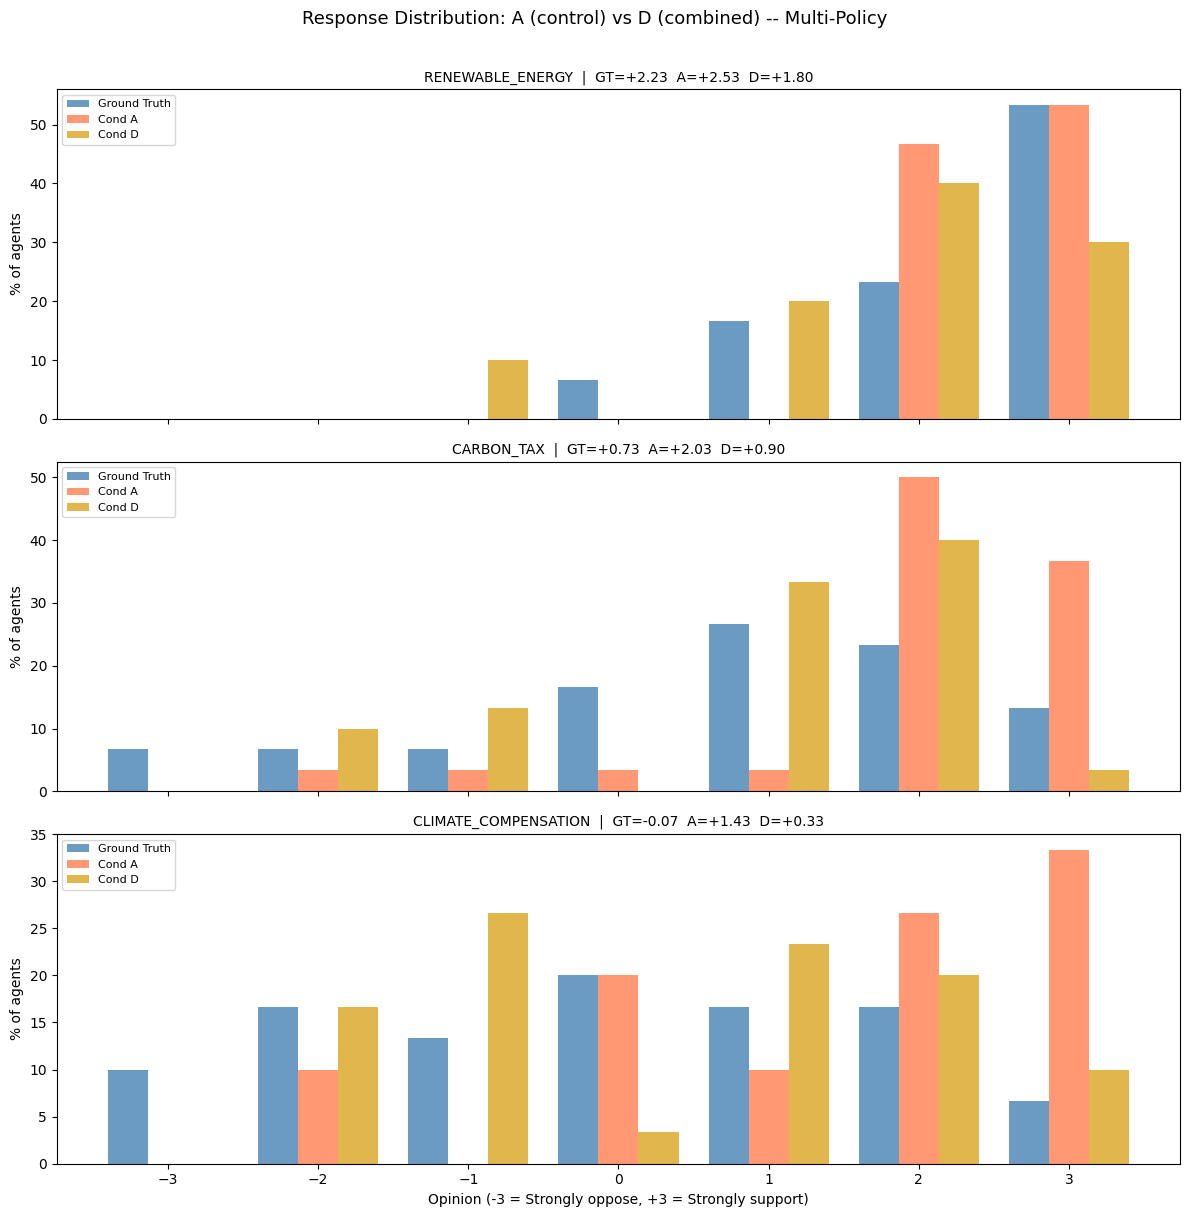

In [11]:
# ── Response distribution per policy: GT vs A vs D ──
import matplotlib.pyplot as plt

scale_values = list(range(-3, 4))
n_policies = len(POLICIES)
cond_colors = {"A": "coral", "D": "goldenrod"}

fig, axes = plt.subplots(n_policies, 1, figsize=(12, 4 * n_policies), sharex=True)
if n_policies == 1:
    axes = [axes]

for idx, policy_id in enumerate(POLICIES):
    ax = axes[idx]
    policy_name = POLICY_NAMES[policy_id]

    gt_vals = [ground_truth[(a.id, policy_id)] for a in agents]
    gt_dist = Counter(gt_vals)
    gt_pcts = [gt_dist.get(v, 0) / len(gt_vals) * 100 for v in scale_values]
    gt_m = mean(gt_vals)

    n_bars = 3  # GT + A + D
    bar_width = 0.8 / n_bars
    x = np.array(scale_values)

    # Ground truth
    ax.bar(x - bar_width, gt_pcts, bar_width, label='Ground Truth', color='steelblue', alpha=0.8)

    # Conditions A and D
    for c_idx, cond in enumerate(CONDITIONS):
        mdf_c = df[(df["policy"] == policy_name) & (df["condition"] == cond) & df["llm_numeric"].notna()]
        dist_c = Counter(mdf_c["llm_numeric"].astype(int))
        n_c = len(mdf_c)
        pcts_c = [dist_c.get(v, 0) / max(n_c, 1) * 100 for v in scale_values]
        offset = c_idx * bar_width
        ax.bar(x + offset, pcts_c, bar_width, label=f'Cond {cond}', color=cond_colors[cond], alpha=0.8)

    # Means for title
    means_str = ""
    for cond in CONDITIONS:
        mdf_c = df[(df["policy"] == policy_name) & (df["condition"] == cond) & df["llm_numeric"].notna()]
        m = mdf_c["llm_numeric"].mean() if len(mdf_c) > 0 else float('nan')
        means_str += f"  {cond}={m:+.2f}"

    ax.set_title(f"{policy_name}  |  GT={gt_m:+.2f}{means_str}", fontsize=10)
    ax.set_ylabel('% of agents')
    ax.set_xticks(scale_values)
    ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel('Opinion (-3 = Strongly oppose, +3 = Strongly support)')
plt.suptitle('Response Distribution: A (control) vs D (combined) -- Multi-Policy', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Scale reversal analysis (Condition D only)

In [12]:
# ── Scale reversal analysis for condition D across policies ──
print("Scale Reversal Effect (Condition D)")
print("=" * 70)
print(f"{'Policy':<25} {'Normal Mean':>12} {'Reversed Mean':>14} {'Delta':>6} {'Normal MAE':>11} {'Reversed MAE':>13}")
print("-" * 85)

for policy_id in POLICIES:
    policy_name = POLICY_NAMES[policy_id]
    mdf = df[(df["policy"] == policy_name) & (df["condition"] == "D") & df["llm_numeric"].notna()].copy()
    if len(mdf) == 0:
        continue

    normal = mdf[mdf["reversed_scale"] == False]
    reversed_ = mdf[mdf["reversed_scale"] == True]

    if len(normal) == 0 or len(reversed_) == 0:
        continue

    nm = normal["llm_numeric"].mean()
    rm = reversed_["llm_numeric"].mean()
    n_mae = normal["abs_error"].mean()
    r_mae = reversed_["abs_error"].mean()

    print(f"{policy_name:<25} {nm:>+11.2f}  {rm:>+13.2f}  {rm-nm:>+5.2f}  {n_mae:>10.2f}  {r_mae:>12.2f}")

print()
print("Large |Delta| -> positional bias persists despite two-step reasoning")

Scale Reversal Effect (Condition D)
Policy                     Normal Mean  Reversed Mean  Delta  Normal MAE  Reversed MAE
-------------------------------------------------------------------------------------
RENEWABLE_ENERGY                +2.13          +1.47  -0.67        1.00          1.20
CARBON_TAX                      +1.40          +0.40  -1.00        1.40          1.07
CLIMATE_COMPENSATION            +0.53          +0.13  -0.40        0.93          1.47

Large |Delta| -> positional bias persists despite two-step reasoning


## Save results

In [13]:
# ── Save ──
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"../data/output/experiments/{timestamp}_multi_policy_generalization"
os.makedirs(out_dir, exist_ok=True)

df.to_csv(f"{out_dir}/per_agent_results.csv", index=False)
summary.to_csv(f"{out_dir}/policy_summary.csv", index=False)
cross.to_csv(f"{out_dir}/cross_policy_summary.csv", index=False)

config = {
    "experiment": "14_multi_policy_generalization",
    "model": MODEL_NAME,
    "conditions": {"A": "control (single-step, A-G letter)", "D": "two-step + anti-sycophancy + numeric + reversal"},
    "policies": [POLICY_NAMES[p] for p in POLICIES],
    "n_agents": N_AGENTS,
    "random_seed": RANDOM_SEED,
    "temperature": TEMPERATURE,
    "thinking": THINKING,
    "nb13_reference": "20260419_002808_mitigation_experiment",
}
with open(f"{out_dir}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Results saved to {out_dir}/")
print()
print(summary[display_cols].to_string(index=False))

Results saved to ../data/output/experiments/20260419_020128_multi_policy_generalization/

              Policy Condition  n   GT Mean  Mean LLM  Exact %  Ordinal  Mean Error      MAE  Direction %  Spearman rho
          CARBON_TAX         A 30  0.733333  2.033333 0.233333 0.750000    1.300000 1.500000     0.666667      0.479408
          CARBON_TAX         D 30  0.733333  0.900000 0.266667 0.794444    0.166667 1.233333     0.666667      0.403863
CLIMATE_COMPENSATION         A 30 -0.066667  1.433333 0.166667 0.683333    1.500000 1.900000     0.400000      0.529579
CLIMATE_COMPENSATION         D 30 -0.066667  0.333333 0.366667 0.800000    0.400000 1.200000     0.600000      0.532570
    RENEWABLE_ENERGY         A 30  2.233333  2.533333 0.400000 0.872222    0.300000 0.766667     0.933333      0.084651
    RENEWABLE_ENERGY         D 30  2.233333  1.800000 0.300000 0.816667   -0.433333 1.100000     0.833333      0.135702


## Conclusion

### Cross-Policy Results (Claude, N=30, seed=44)

| Policy | GT Mean | A Mean Err | D Mean Err | Bias Reduction | Δ MAE | Wilcoxon p |
|---|---|---|---|---|---|---|
| **Ban Petrol Cars** (NB 13) | +0.07 | +1.067 | +0.033 | **+97%** | -0.10 | ns |
| **Carbon Tax** | +0.73 | +1.300 | +0.167 | **+87%** | -0.27 | ns |
| **Climate Compensation** | -0.07 | +1.500 | +0.400 | **+73%** | **-0.70** | **p=0.006** |
| **Renewable Energy** | +2.23 | +0.300 | -0.433 | **-44%** ⚠️ | +0.33 | ns |

### Key Findings

1. **D generalizes to 3 of 4 policies.** Bias reduction exceeds +73% for Ban Petrol Cars, Carbon Tax, and Climate Compensation — the three policies with moderate-to-high opinion diversity.

2. **D overcorrects on Renewable Energy.** This is the most consensual policy (GT mean = +2.23). The anti-sycophancy instruction pushes the LLM to find opposition where little exists in the real population. Condition A's small bias (+0.30) becomes a negative bias (-0.43) under D, and MAE worsens (+0.33).

3. **Climate Compensation shows the only significant individual-level MAE improvement** (p=0.006, 18↑ 5↓ 7=). This is also the policy with the lowest GT mean (-0.07) and the highest baseline bias (+1.50) — i.e. the most room for improvement.

4. **Scale reversal Δ is consistently negative** across all 3 policies (-0.40 to -1.00), confirming positional/primacy bias persists but is balanced by the 50/50 split design.

5. **Condition A compresses responses to the positive end** — Renewable Energy A produces only 2s and 3s; Carbon Tax A produces mostly 2s and 3s. Condition D restores variance across all policies.

### Decision

The decision rule (D reduces bias by >50% for ≥3 of 4 policies) is **MET**.

**Recommendation:** Integrate Condition D into `administer_survey()` with one caveat:
- For highly consensual policies (GT mean > +2.0), D's anti-sycophancy may overcorrect. Consider a lighter variant or skip anti-sycophancy for policies where the real population is near-unanimous. This is a refinement for later — the current D is a clear net improvement over A for the aggregate baseline.

### What This Means for the Simulation

- **Day 0 baseline** will be substantially more accurate for 3/4 policies tested.
- The **~1.7 MAE floor** at the individual level persists (except Climate Compensation). This is likely an irreducible limit of prompting a single LLM to predict individual survey responses.
- The simulation's **dynamic behavior** (days 1-7) should be less confounded by baseline inflation, making it easier to isolate the effect of political agent messaging.